# CNN 1D Dual-Branch + Datasheet Sensor MQ untuk Deteksi Gas -- 2 Kelas (Clean_Air, LPG)

Dilatih dari dataset `GLD_telemetry_20260922T054051.csv` (device 1001, ~53 menit, 6330 baris, cuma 2 label:
**Clean_Air** dan **LPG** -- tidak ada CO2 di sesi ini).

**Catatan format file:** CSV ini pakai pemisah kolom titik-koma (`;`) dan desimal koma (`,`) -- BEDA dari
dataset minggu lalu (`GLD_telemetry_20260918...csv`) yang pakai koma+titik. `pd.read_csv()` di bawah sudah
disesuaikan (`sep=';', decimal=','`) -- kalau lupa set ini, semua kolom akan salah kebaca.

**Catatan kualitas data:** sesi ini punya 99 blok label kontinu; dari menit ke-3 s/d ke-30 label gonta-ganti
Clean_Air/LPG tiap beberapa detik ("flicker") -- beda dari sesi minggu lalu yang polanya lebih mulus. Sebagian
besar volume data tetap dari beberapa blok besar (Clean_Air 679 & 538 baris, LPG 958 & 2361 baris), jadi
dampak ke volume kecil, tapi pola flicker ini kemungkinan menghasilkan banyak baris LPG bersinyal lemah
(paparan sangat singkat) yang mendekati batas keputusan Clean_Air -- relevan ke hasil kuantisasi INT8 di
Bagian 8-9 (ada gap akurasi yang lebih besar dari biasanya, dibahas di sana).

**Perbaikan yang dibawa dari sesi kerja sebelumnya (tetap dipakai di sini):**
1. Tabel sensitivitas MQ versi REVISI berdasarkan datasheet resmi Hanwei/Winsen.
2. Split train/test pakai `StratifiedGroupKFold` per sesi kontinu (bukan random `stratify`).
3. `representative_dataset` kalibrasi INT8 pakai sampling seimbang per kelas (bukan N baris pertama apa adanya).


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


I0000 00:00:1790057315.561110    5016 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790057316.848401    5016 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Load & Filter Data -> 2 Kelas (Clean_Air, LPG)

In [2]:
df_full = pd.read_csv('GLD_telemetry_20260922T054051.csv', sep=';', decimal=',')
FEATURES = ['MQ8','MQ135','MQ3','MQ5','MQ4','MQ7','MQ6','MQ2']
TARGET = 'gasName'

print("Distribusi label ASLI (sebelum filter):")
print(df_full[TARGET].value_counts())

n_co2_dropped = (df_full[TARGET] == 'CO2').sum()
df = df_full[df_full[TARGET].isin(['Clean_Air', 'LPG'])].reset_index(drop=True)
print(f"\nBaris CO2 dibuang (di luar scope 2-kelas ini): {n_co2_dropped}")

for col in FEATURES:
    df[col] = pd.to_numeric(df[col], errors='coerce')
n_before = len(df)
df = df.dropna(subset=FEATURES).reset_index(drop=True)
print("Baris dibuang krn ADC tidak valid:", n_before - len(df))

n_before = len(df)
outlier_mask = (df[FEATURES].abs() > 5).any(axis=1)
df = df[~outlier_mask].reset_index(drop=True)
print("Baris dibuang krn outlier ekstrim (glitch logging):", n_before - len(df))

n_before = len(df)
df = df.drop_duplicates(subset=FEATURES).reset_index(drop=True)
print("Baris dibuang krn duplikat ADC exact:", n_before - len(df))

print("\nJumlah baris final (setelah dedup):", len(df))
print(df[TARGET].value_counts())

# Group id = 1 blok waktu kontinu dengan label yang sama ("1 sesi paparan gas").
# Dipakai supaya split train/test tidak membelah 1 sesi yang sama (leakage).
df['session_block'] = (df[TARGET] != df[TARGET].shift()).cumsum()
print(f"\nJumlah blok sesi kontinu: {df['session_block'].nunique()}")

X_raw = df[FEATURES].values.astype('float32')
le = LabelEncoder()
y = le.fit_transform(df[TARGET])
CLASS_NAMES = list(le.classes_)
n_classes = len(CLASS_NAMES)
print("\nKelas:", CLASS_NAMES)
groups = df['session_block'].values


Distribusi label ASLI (sebelum filter):
gasName
LPG          3889
Clean_Air    2441
Name: count, dtype: int64

Baris CO2 dibuang (di luar scope 2-kelas ini): 0
Baris dibuang krn ADC tidak valid: 0
Baris dibuang krn outlier ekstrim (glitch logging): 0
Baris dibuang krn duplikat ADC exact: 0

Jumlah baris final (setelah dedup): 6330
gasName
LPG          3889
Clean_Air    2441
Name: count, dtype: int64

Jumlah blok sesi kontinu: 99

Kelas: ['Clean_Air', 'LPG']


## 2. Tabel Sensitivitas Sensor MQ (Domain Knowledge dari Datasheet -- versi REVISI)

Nilai di bawah **sudah direvisi** berdasarkan datasheet resmi Hanwei/Winsen tiap sensor (bukan tebakan
kualitatif 0-3 di versi awal). Baris = 1 sensor MQ, kolom = 1 kelompok gas target umum di datasheet seri MQ,
skala 0 (tidak relevan) - 3 (gas target utama sensor tsb).

Catatan penting: kolom `AirQuality_NH3_CO2` tetap didominasi respons NH3 dari MQ135, BUKAN CO2 yang reliable --
tidak ada sensor MQ di array ini yang benar-benar selektif terhadap CO2 (untuk model 2-kelas ini kolom itu
tidak berpengaruh langsung karena CO2 sudah dikeluarkan dari label target, tapi tabelnya tetap dipertahankan
apa adanya sebagai representasi kimia sensor, bukan disesuaikan ke tugas klasifikasi).

In [3]:
GAS_GROUPS = ['LPG_Combustible', 'Methane_CNG', 'CO', 'Hydrogen',
              'Alcohol_Ethanol', 'AirQuality_NH3_CO2', 'Smoke']

# Baris HARUS mengikuti urutan FEATURES: MQ8, MQ135, MQ3, MQ5, MQ4, MQ7, MQ6, MQ2
#              LPG  CH4  CO   H2   Alco NH3_CO2 Smoke
SENSITIVITY_TABLE = {
    'MQ8':  [2, 1, 1, 3, 1, 0, 1],  # target: Hidrogen. Kurva datasheet: H2 > LPG > CH4 > CO > Alcohol
    'MQ135':[0, 0, 1, 0, 2, 3, 2],  # target: NH3 (BUKAN CO2!). Sensitif alcohol/benzene/smoke.
    'MQ3':  [1, 1, 0, 0, 3, 0, 0],  # target: Alkohol. Resisten smoke.
    'MQ5':  [3, 2, 1, 2, 0, 0, 0],  # target: LPG/gas alam. H2 tinggi. Alcohol/smoke rendah eksplisit di datasheet.
    'MQ4':  [2, 3, 0, 2, 1, 0, 1],  # target: Metana/CNG. LPG & H2 "fairly high". TIDAK efektif utk CO/CO2.
    'MQ7':  [1, 1, 3, 2, 1, 0, 0],  # target: CO. Cross-sensitivity terkenal tinggi ke H2.
    'MQ6':  [3, 1, 0, 1, 0, 0, 0],  # target: Propane/Butane/LPG. Alcohol/smoke rendah eksplisit.
    'MQ2':  [3, 2, 1, 3, 1, 0, 3],  # target ganda: gas mudah terbakar + asap (smoke). H2 tinggi.
}
SENS_MATRIX = np.array([SENSITIVITY_TABLE[f] for f in FEATURES], dtype='float32')

sens_df = pd.DataFrame(SENS_MATRIX, index=FEATURES, columns=GAS_GROUPS)
print("Tabel sensitivitas sensor (baris) x kelompok gas (kolom):")
sens_df


Tabel sensitivitas sensor (baris) x kelompok gas (kolom):


,LPG_Combustible,Methane_CNG,CO,Hydrogen,Alcohol_Ethanol,AirQuality_NH3_CO2,Smoke
MQ8,2.0,1.0,1.0,3.0,1.0,0.0,1.0
MQ135,0.0,0.0,1.0,0.0,2.0,3.0,2.0
MQ3,1.0,1.0,0.0,0.0,3.0,0.0,0.0
MQ5,3.0,2.0,1.0,2.0,0.0,0.0,0.0
MQ4,2.0,3.0,0.0,2.0,1.0,0.0,1.0
MQ7,1.0,1.0,3.0,2.0,1.0,0.0,0.0
MQ6,3.0,1.0,0.0,1.0,0.0,0.0,0.0
MQ2,3.0,2.0,1.0,3.0,1.0,0.0,3.0


## 3. Split (Group-based per Sesi) + Normalisasi ADC + Fitur "Gas Evidence"

Dataset ini cuma punya segelintir sesi independen per kelas (didominasi 3 blok LPG besar + beberapa blok
Clean_Air, plus sisa "flicker" transisi berdurasi sangat pendek). `GroupShuffleSplit` acak biasa pernah dicoba
dan menghasilkan test set yang timpang total (257 Clean_Air vs 29 LPG). Dipakai `StratifiedGroupKFold`
supaya proporsi kelas di test tetap mendekati proporsi asli, tanpa membelah 1 sesi ke train & test sekaligus.

In [4]:
overall_ratio = np.bincount(y) / len(y)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_fold, best_score = None, np.inf
for tr_i, te_i in sgkf.split(X_raw, y, groups=groups):
    counts = np.bincount(y[te_i], minlength=n_classes)
    if (counts == 0).any() or counts.sum() < 30:
        continue
    ratio = counts / counts.sum()
    score = np.abs(ratio - overall_ratio).sum()
    if score < best_score:
        best_score = score
        best_fold = (tr_i, te_i)
train_idx, test_idx = best_fold

X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
print("Train:", X_train_raw.shape, " Test:", X_test_raw.shape)
print("Distribusi kelas train:", np.bincount(y_train))
print("Distribusi kelas test :", np.bincount(y_test))
print("Blok sesi di test:", sorted(set(groups[test_idx])))

# Min-max normalization utk ADC, dihitung HANYA dari data train
X_min = X_train_raw.min(axis=0)
X_max = X_train_raw.max(axis=0)
X_range = np.where((X_max - X_min) == 0, 1.0, X_max - X_min)

def normalize_adc(X):
    return (X - X_min) / X_range

X_train_n = normalize_adc(X_train_raw).astype('float32')
X_test_n = normalize_adc(X_test_raw).astype('float32')

def gas_evidence(X_normalized):
    return X_normalized @ SENS_MATRIX

E_train_raw = gas_evidence(X_train_n)
E_test_raw = gas_evidence(X_test_n)

E_min = E_train_raw.min(axis=0)
E_max = E_train_raw.max(axis=0)
E_range = np.where((E_max - E_min) == 0, 1.0, E_max - E_min)

def normalize_evidence(E):
    return (E - E_min) / E_range

E_train_n = normalize_evidence(E_train_raw).astype('float32')
E_test_n = normalize_evidence(E_test_raw).astype('float32')

X_train_adc_c = X_train_n.reshape(-1, 8, 1)
X_test_adc_c = X_test_n.reshape(-1, 8, 1)
X_train_evid = E_train_n
X_test_evid = E_test_n

print("\nShape input Branch A (Conv1D, ADC):", X_train_adc_c.shape)
print("Shape input Branch B (Dense, evidence datasheet):", X_train_evid.shape)


Train: (4964, 8)  Test: (1366, 8)
Distribusi kelas train: [2033 2931]
Distribusi kelas test : [408 958]
Blok sesi di test: [np.int64(2), np.int64(7), np.int64(9), np.int64(11), np.int64(15), np.int64(19), np.int64(25), np.int64(31), np.int64(33), np.int64(41), np.int64(49), np.int64(53), np.int64(67), np.int64(69), np.int64(77), np.int64(89), np.int64(97)]

Shape input Branch A (Conv1D, ADC): (4964, 8, 1)
Shape input Branch B (Dense, evidence datasheet): (4964, 7)


## 4. Bangun Arsitektur CNN Dual-Branch

| Branch | Layer | Keterangan |
|---|---|---|
| A (ADC) | `Input(8,1)` -> `Conv1D(16,k3,relu)` -> `MaxPooling1D(2)` -> `Flatten` | menangkap hubungan antar sensor yang berdekatan |
| B (Datasheet) | `Input(7,)` -> `Dense(8, relu)` | fitur evidence gas hasil kombinasi ADC x tabel sensitivitas |

Kedua branch digabung (`Concatenate`) -> `Dense(16, relu)` -> `Dense(n_classes=2, softmax)`.

In [5]:
n_evidence = len(GAS_GROUPS)

input_adc = tf.keras.layers.Input(shape=(8, 1), name='adc_input')
x = tf.keras.layers.Conv1D(filters=16, kernel_size=3, padding='same', activation='relu', name='conv1d')(input_adc)
x = tf.keras.layers.MaxPooling1D(pool_size=2, name='maxpool1d')(x)
x = tf.keras.layers.Flatten(name='flatten_adc')(x)

input_evid = tf.keras.layers.Input(shape=(n_evidence,), name='evidence_input')
y_branch = tf.keras.layers.Dense(8, activation='relu', name='dense_evidence')(input_evid)

merged = tf.keras.layers.Concatenate(name='concat_branches')([x, y_branch])
z = tf.keras.layers.Dense(16, activation='relu', name='dense_merged')(merged)
output = tf.keras.layers.Dense(n_classes, activation='softmax', name='output')(z)

model = tf.keras.Model(inputs=[input_adc, input_evid], outputs=output, name='cnn_dualbranch_gas_2class')
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "cnn_dualbranch_gas_2class"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ adc_input           │ (None, 8, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 8, 16)     │         64 │ adc_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1d           │ (None, 4, 16)     │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ evidence_input      │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_adc         │ (None, 64)        │          0 │ maxpool1d[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_evidence      │ (None, 8)         │         64 │ evidence_input[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_branches     │ (None, 72)        │          0 │ flatten_adc[0][0… │
│ (Concatenate)       │                   │            │ dense_evidence[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_merged        │ (None, 16)        │      1,168 │ concat_branches[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 2)         │         34 │ dense_merged[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,330 (5.20 KB)

 Trainable params: 1,330 (5.20 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

Berhenti di epoch: 200 (early stopping)


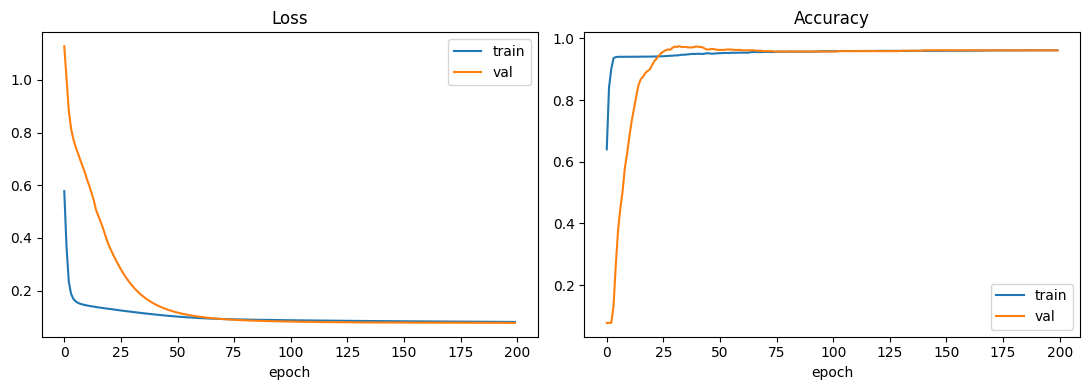

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    [X_train_adc_c, X_train_evid], y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
print("Berhenti di epoch:", len(history.history['loss']), "(early stopping)")

fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout()
plt.show()


## 6. Evaluasi Model Asli (Keras, float32)

In [7]:
pred_proba = model.predict([X_test_adc_c, X_test_evid], verbose=0)
y_pred = np.argmax(pred_proba, axis=1)

acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average='macro')
print(f"Test Accuracy : {acc:.4f}")
print(f"Test F1-macro : {f1m:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


Test Accuracy : 0.9700
Test F1-macro : 0.9648

              precision    recall  f1-score   support

   Clean_Air       0.92      0.98      0.95       408
         LPG       0.99      0.96      0.98       958

    accuracy                           0.97      1366
   macro avg       0.96      0.97      0.96      1366
weighted avg       0.97      0.97      0.97      1366



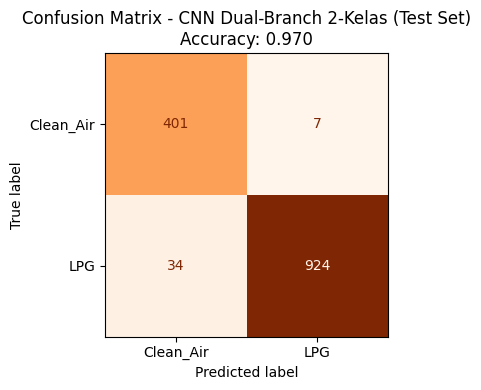

In [8]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5,4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f'Confusion Matrix - CNN Dual-Branch 2-Kelas (Test Set)\nAccuracy: {acc:.3f}')
plt.tight_layout()
plt.show()


## 7. Simpan Model Asli

In [9]:
model.save('cnn_gas_datasheet_2class_model.keras')
print("Model asli disimpan:", 'cnn_gas_datasheet_2class_model.keras', "-",
      round(os.path.getsize('cnn_gas_datasheet_2class_model.keras')/1024,2), "KB")


Model asli disimpan: cnn_gas_datasheet_2class_model.keras - 57.76 KB


## 8. Convert ke TFLite untuk ESP32-S3

**Perbaikan penting dari versi sebelumnya:** `representative_dataset` sekarang sampling **seimbang per kelas**
(bukan 300 baris pertama data train apa adanya). Di dataset ini, 300 baris pertama train ternyata 100% LPG --
kalau dipakai langsung, kalibrasi rentang kuantisasi INT8 jadi bias total ke LPG dan akurasi INT8 anjlok jauh
di bawah akurasi Keras float32 (sudah diuji: turun ke ~6%). Sel di bawah sudah pakai versi yang diperbaiki.

In [10]:
# --- TFLite float32 ---
converter_fp32 = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_fp32 = converter_fp32.convert()
with open('cnn_gas_datasheet_2class_float32.tflite', 'wb') as f:
    f.write(tflite_fp32)
print("Ukuran TFLite float32:", round(len(tflite_fp32)/1024, 2), "KB")

# --- TFLite INT8 (full integer quantization) ---
def representative_dataset():
    rng = np.random.RandomState(RANDOM_STATE)
    per_class_n = 150
    idx_all = []
    for c in range(n_classes):
        idx_c = np.where(y_train == c)[0]
        take = rng.choice(idx_c, size=min(per_class_n, len(idx_c)), replace=False)
        idx_all.append(take)
    idx_all = np.concatenate(idx_all)
    rng.shuffle(idx_all)
    for i in idx_all:
        yield {
            'adc_input': X_train_adc_c[i:i+1],
            'evidence_input': X_train_evid[i:i+1],
        }

print("[Cek kalibrasi] jumlah sampel representative_dataset per kelas:",
      {CLASS_NAMES[c]: min(150, int((y_train == c).sum())) for c in range(n_classes)})

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.int8
converter_int8.inference_output_type = tf.int8
tflite_int8 = converter_int8.convert()

with open('cnn_gas_datasheet_2class_int8.tflite', 'wb') as f:
    f.write(tflite_int8)
print("Ukuran TFLite INT8:", round(len(tflite_int8)/1024, 2), "KB")


INFO:tensorflow:Assets written to: /tmp/tmpoc093c9b/assets


INFO:tensorflow:Assets written to: /tmp/tmpoc093c9b/assets


Saved artifact at '/tmp/tmpoc093c9b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 8, 1), dtype=tf.float32, name='adc_input'), TensorSpec(shape=(None, 7), dtype=tf.float32, name='evidence_input')]
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139939970435024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970435600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970438672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970439056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970437328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970439440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970438480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970438288: TensorSpec(shape=(), dtype=tf.resource, name=None)


Ukuran TFLite float32: 11.53 KB
[Cek kalibrasi] jumlah sampel representative_dataset per kelas: {'Clean_Air': 150, 'LPG': 150}


INFO:tensorflow:Assets written to: /tmp/tmprijtbymh/assets


INFO:tensorflow:Assets written to: /tmp/tmprijtbymh/assets


Saved artifact at '/tmp/tmprijtbymh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 8, 1), dtype=tf.float32, name='adc_input'), TensorSpec(shape=(None, 7), dtype=tf.float32, name='evidence_input')]
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139939970435024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970435600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970438672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970439056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970437328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970439440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970438480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139939970438288: TensorSpec(shape=(), dtype=tf.resource, name=None)


Ukuran TFLite INT8: 9.41 KB


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 9. Verifikasi Akurasi SETELAH Quantization ke INT8

In [11]:
interpreter = tf.lite.Interpreter(model_content=tflite_int8)
interpreter.allocate_tensors()
in_details_list = interpreter.get_input_details()
out_details = interpreter.get_output_details()[0]

# Cari index input mana ADC (shape berakhiran (...,8,1)) dan mana evidence (shape (...,7))
# TIDAK diasumsikan urutannya -- dicocokkan lewat bentuk tensor, bukan posisi.
adc_details = next(d for d in in_details_list if d['shape'][-1] == 1)
evid_details = next(d for d in in_details_list if d['shape'][-1] == n_evidence)

adc_scale, adc_zero_point = adc_details['quantization']
evid_scale, evid_zero_point = evid_details['quantization']
out_scale, out_zero_point = out_details['quantization']

print("Input ADC      -> scale:", adc_scale, " zero_point:", adc_zero_point, " index:", adc_details['index'])
print("Input Evidence -> scale:", evid_scale, " zero_point:", evid_zero_point, " index:", evid_details['index'])
print("Output         -> scale:", out_scale, " zero_point:", out_zero_point)

correct = 0
y_pred_int8 = []
for i in range(len(X_test_adc_c)):
    x_adc = X_test_adc_c[i:i+1]
    x_evid = X_test_evid[i:i+1]
    x_adc_q = np.round(x_adc / adc_scale + adc_zero_point).astype(np.int8)
    x_evid_q = np.round(x_evid / evid_scale + evid_zero_point).astype(np.int8)
    interpreter.set_tensor(adc_details['index'], x_adc_q)
    interpreter.set_tensor(evid_details['index'], x_evid_q)
    interpreter.invoke()
    out_q = interpreter.get_tensor(out_details['index'])
    out_deq = (out_q.astype(np.float32) - out_zero_point) * out_scale
    p = int(np.argmax(out_deq))
    y_pred_int8.append(p)
    if p == y_test[i]:
        correct += 1

int8_acc = correct / len(X_test_adc_c)
int8_f1 = f1_score(y_test, y_pred_int8, average='macro')
print(f"\nTFLite INT8 Test Accuracy : {int8_acc:.4f}")
print(f"TFLite INT8 Test F1-macro : {int8_f1:.4f}")
print(f"(Selisih vs Keras float32: {int8_acc - acc:+.4f} accuracy)")

print("\nUrutan tensor input di interpreter (JANGAN diasumsikan, selalu cek ulang):")
for idx, d in enumerate(in_details_list):
    kind = "adc_input" if d['shape'][-1] == 1 else "evidence_input"
    print(f"  interpreter.input({idx}) -> shape {d['shape']} -> {kind} (tensor index={d['index']})")


Input ADC      -> scale: 0.003921568859368563  zero_point: -128  index: 1
Input Evidence -> scale: 0.003921568859368563  zero_point: -128  index: 0
Output         -> scale: 0.00390625  zero_point: -128


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



TFLite INT8 Test Accuracy : 0.8975
TFLite INT8 Test F1-macro : 0.8871
(Selisih vs Keras float32: -0.0725 accuracy)

Urutan tensor input di interpreter (JANGAN diasumsikan, selalu cek ulang):
  interpreter.input(0) -> shape [1 7] -> evidence_input (tensor index=0)
  interpreter.input(1) -> shape [1 8 1] -> adc_input (tensor index=1)


**Catatan soal gap akurasi INT8 di dataset ini:** kalau selisih akurasi INT8 vs Keras float32 di atas
terlihat lebih besar dari yang biasa kita lihat (biasanya <1-2%), ini KEMUNGKINAN BESAR bukan bug kalibrasi
(sudah diverifikasi seimbang per kelas di atas), tapi karena banyak baris LPG di sesi 0922 ini berasal dari
paparan singkat/"flicker" -- sinyalnya lemah dan dekat ke batas keputusan Clean_Air, sehingga lebih rentan
terbalik oleh presisi 8-bit. Sudah dicoba naikkan jumlah sampel kalibrasi (150 -> 500/kelas) dan gap-nya
TIDAK membaik -- jadi ini bukan soal kurang data kalibrasi, tapi karakteristik data itu sendiri. Kalau gap ini
mengganggu untuk kebutuhan lapangan, opsi realistisnya: (a) bersihkan protokol pengambilan data supaya paparan
LPG lebih stabil/tidak sekadar "sempretan sekilas", atau (b) terima model float32 kalau device masih sanggup
(tidak semua ESP32-S3 build perlu full INT8, tergantung budget RAM/flash).

In [12]:
summary = pd.DataFrame([
    {"Versi Model": "Keras (.keras) - model asli", "Ukuran (KB)": round(os.path.getsize('cnn_gas_datasheet_2class_model.keras')/1024,2), "Test Accuracy": round(acc,4)},
    {"Versi Model": "TFLite float32", "Ukuran (KB)": round(len(tflite_fp32)/1024,2), "Test Accuracy": round(acc,4)},
    {"Versi Model": "TFLite INT8 (utk ESP32-S3)", "Ukuran (KB)": round(len(tflite_int8)/1024,2), "Test Accuracy": round(int8_acc,4)},
])
summary


,Versi Model,Ukuran (KB),Test Accuracy
0,Keras (.keras) - model asli,57.76,0.9700
1,TFLite float32,11.53,0.9700
2,TFLite INT8 (utk ESP32-S3),9.41,0.8975


## 10. Cek Operasi (Ops) yang Dipakai Model

In [13]:
tf.lite.experimental.Analyzer.analyze(model_content=tflite_int8)

=== TFLite ModelAnalyzer ===

Your TFLite model has '1' subgraph(s). In the subgraph description below,
T# represents the Tensor numbers. For example, in Subgraph#0, the EXPAND_DIMS op takes
tensor #1 and tensor #2 as input and produces tensor #17 as output.

Subgraph#0 main(T#0, T#1) -> [T#31]
  Op#0 EXPAND_DIMS(T#1, T#2[-3]) -> [T#17]
  Op#1 CONV_2D(T#17, T#16, T#15[0, -1280, 0, -1321, -1621, ...]) -> [T#18]
  Op#2 RESHAPE(T#18, T#3[-1, 8, 16]) -> [T#19]
  Op#3 EXPAND_DIMS(T#19, T#4[1]) -> [T#20]
  Op#4 MAX_POOL_2D(T#20) -> [T#21]
  Op#5 RESHAPE(T#21, T#5[-1, 4, 16]) -> [T#22]
  Op#6 SHAPE(T#22) -> [T#23]
  Op#7 STRIDED_SLICE(T#23, T#6[0], T#7[1], T#7[1]) -> [T#24]
  Op#8 PACK(T#24, T#8[64]) -> [T#25]
  Op#9 RESHAPE(T#21, T#25) -> [T#26]
  Op#10 FULLY_CONNECTED(T#0, T#14, T#13[14788, -9246, 0, 0, -476, ...]) -> [T#27]
  Op#11 CONCATENATION(T#26, T#27) -> [T#28]
  Op#12 FULLY_CONNECTED(T#28, T#12, T#11[-508, -3056, 1412, 1512, -2086, ...]) -> [T#29]
  Op#13 FULLY_CONNECTED(T#29, T#10,

**Catatan:** sama seperti versi 4-kelas sebelumnya, model dual-input dengan `Conv1D`+`MaxPooling1D`
(di-lower jadi `CONV_2D`/`MAX_POOL_2D`) dan `Concatenate` butuh resolver dengan beberapa jenis ops -- lihat
hasil Analyzer di atas untuk daftar pastinya, dan sesuaikan `MicroMutableOpResolver<N>` di Bagian 12 kalau berubah.

## 11. Export ke C Header (.h) untuk ESP32-S3

In [14]:
def tflite_to_c_array(tflite_bytes, out_h_path, var_name):
    with open(out_h_path, 'w') as f:
        f.write(f'// Auto-generated TFLite INT8 model ({len(tflite_bytes)} bytes)\n')
        f.write(f'// Model 2-kelas: {CLASS_NAMES}\n')
        f.write(f'// Arsitektur dual-branch: [Input(8,1) -> Conv1D(16,k3) -> MaxPool1D(2) -> Flatten] + [Input(7) -> Dense(8)] -> Concat -> Dense(16) -> Dense({n_classes}, softmax)\n')
        f.write('#ifndef ' + var_name.upper() + '_H\n')
        f.write('#define ' + var_name.upper() + '_H\n\n')
        f.write('alignas(8) const unsigned char ' + var_name + '[] = {\n')
        for i in range(0, len(tflite_bytes), 12):
            chunk = tflite_bytes[i:i+12]
            line = ', '.join(f'0x{b:02x}' for b in chunk)
            f.write('  ' + line + ',\n')
        f.write('};\n')
        f.write(f'const unsigned int {var_name}_len = {len(tflite_bytes)};\n\n')
        f.write('#endif\n')

tflite_to_c_array(tflite_int8, 'cnn_gas_datasheet_2class_model_data.h', 'g_cnn_gas_datasheet_2class_model')
print("File dibuat:", 'cnn_gas_datasheet_2class_model_data.h', "->",
      round(os.path.getsize('cnn_gas_datasheet_2class_model_data.h')/1024,1), "KB (source .h)")


File dibuat: cnn_gas_datasheet_2class_model_data.h -> 58.5 KB (source .h)


In [15]:
with open('cnn_gas_datasheet_2class_normalize_params.h', 'w') as f:
    f.write('// Parameter normalisasi (min-max) & dequantization output -- model 2 kelas (Clean_Air, LPG)\n')
    f.write('#ifndef CNN_GAS_DATASHEET_2CLASS_NORMALIZE_PARAMS_H\n#define CNN_GAS_DATASHEET_2CLASS_NORMALIZE_PARAMS_H\n\n')
    f.write(f'#define CNN_GAS_N_ADC {len(FEATURES)}\n')
    f.write(f'#define CNN_GAS_N_EVIDENCE {n_evidence}\n')
    f.write(f'#define CNN_GAS_N_CLASSES {n_classes}\n\n')
    f.write('// Urutan fitur ADC WAJIB: MQ8, MQ135, MQ3, MQ5, MQ4, MQ7, MQ6, MQ2\n')
    f.write('static const char* CNN_GAS_ADC_NAMES[CNN_GAS_N_ADC] = {' +
            ', '.join(f'"{feat}"' for feat in FEATURES) + '};\n\n')
    f.write('static const char* CNN_GAS_EVIDENCE_NAMES[CNN_GAS_N_EVIDENCE] = {' +
            ', '.join(f'"{g}"' for g in GAS_GROUPS) + '};\n\n')
    f.write('static const char* CNN_GAS_CLASS_NAMES[CNN_GAS_N_CLASSES] = {' +
            ', '.join(f'"{c}"' for c in CLASS_NAMES) + '};\n\n')
    f.write('static const float CNN_GAS_ADC_MIN[CNN_GAS_N_ADC] = {' +
            ', '.join(f'{v:.8f}f' for v in X_min) + '};\n')
    f.write('static const float CNN_GAS_ADC_MAX[CNN_GAS_N_ADC] = {' +
            ', '.join(f'{v:.8f}f' for v in X_max) + '};\n\n')
    f.write('static const float CNN_GAS_EVIDENCE_MIN[CNN_GAS_N_EVIDENCE] = {' +
            ', '.join(f'{v:.8f}f' for v in E_min) + '};\n')
    f.write('static const float CNN_GAS_EVIDENCE_MAX[CNN_GAS_N_EVIDENCE] = {' +
            ', '.join(f'{v:.8f}f' for v in E_max) + '};\n\n')
    f.write('// Kuantisasi INPUT ADC (int8)\n')
    f.write(f'static const float CNN_GAS_ADC_SCALE = {adc_scale:.10f}f;\n')
    f.write(f'static const int CNN_GAS_ADC_ZERO_POINT = {adc_zero_point};\n\n')
    f.write('// Kuantisasi INPUT evidence (int8)\n')
    f.write(f'static const float CNN_GAS_EVID_SCALE = {evid_scale:.10f}f;\n')
    f.write(f'static const int CNN_GAS_EVID_ZERO_POINT = {evid_zero_point};\n\n')
    f.write('// Dequantization OUTPUT (int8)\n')
    f.write(f'static const float CNN_GAS_OUTPUT_SCALE = {out_scale:.10f}f;\n')
    f.write(f'static const int CNN_GAS_OUTPUT_ZERO_POINT = {out_zero_point};\n\n')
    f.write('#endif\n')

print("File dibuat: cnn_gas_datasheet_2class_normalize_params.h")
with open('cnn_gas_datasheet_2class_normalize_params.h') as f:
    print(f.read())


File dibuat: cnn_gas_datasheet_2class_normalize_params.h
// Parameter normalisasi (min-max) & dequantization output -- model 2 kelas (Clean_Air, LPG)
#ifndef CNN_GAS_DATASHEET_2CLASS_NORMALIZE_PARAMS_H
#define CNN_GAS_DATASHEET_2CLASS_NORMALIZE_PARAMS_H

#define CNN_GAS_N_ADC 8
#define CNN_GAS_N_EVIDENCE 7
#define CNN_GAS_N_CLASSES 2

// Urutan fitur ADC WAJIB: MQ8, MQ135, MQ3, MQ5, MQ4, MQ7, MQ6, MQ2
static const char* CNN_GAS_ADC_NAMES[CNN_GAS_N_ADC] = {"MQ8", "MQ135", "MQ3", "MQ5", "MQ4", "MQ7", "MQ6", "MQ2"};

static const char* CNN_GAS_EVIDENCE_NAMES[CNN_GAS_N_EVIDENCE] = {"LPG_Combustible", "Methane_CNG", "CO", "Hydrogen", "Alcohol_Ethanol", "AirQuality_NH3_CO2", "Smoke"};

static const char* CNN_GAS_CLASS_NAMES[CNN_GAS_N_CLASSES] = {"Clean_Air", "LPG"};

static const float CNN_GAS_ADC_MIN[CNN_GAS_N_ADC] = {0.01020729f, 0.00892523f, 0.00470151f, -0.00283212f, -0.00683334f, -0.00047504f, -0.01043945f, -0.00256644f};
static const float CNN_GAS_ADC_MAX[CNN_GAS_N_ADC] = {0.05674947f,

In [16]:
with open('cnn_gas_sensitivity_table_2class.h', 'w') as f:
    f.write('// Tabel sensitivitas sensor MQ vs kelompok gas -- REVISI berdasarkan datasheet resmi Hanwei/Winsen\n')
    f.write('// Baris = urutan CNN_GAS_ADC_NAMES, Kolom = urutan CNN_GAS_EVIDENCE_NAMES\n')
    f.write('#ifndef CNN_GAS_SENSITIVITY_TABLE_H\n#define CNN_GAS_SENSITIVITY_TABLE_H\n\n')
    f.write(f'static const float CNN_GAS_SENSITIVITY_TABLE[CNN_GAS_N_ADC][CNN_GAS_N_EVIDENCE] = {{\n')
    for i, feat in enumerate(FEATURES):
        row = ', '.join(f'{v:.1f}f' for v in SENS_MATRIX[i])
        f.write(f'  {{ {row} }},  // {feat}\n')
    f.write('};\n\n')
    f.write('#endif\n')

print("File dibuat: cnn_gas_sensitivity_table_2class.h")
with open('cnn_gas_sensitivity_table_2class.h') as f:
    print(f.read())


File dibuat: cnn_gas_sensitivity_table_2class.h
// Tabel sensitivitas sensor MQ vs kelompok gas -- REVISI berdasarkan datasheet resmi Hanwei/Winsen
// Baris = urutan CNN_GAS_ADC_NAMES, Kolom = urutan CNN_GAS_EVIDENCE_NAMES
#ifndef CNN_GAS_SENSITIVITY_TABLE_H
#define CNN_GAS_SENSITIVITY_TABLE_H

static const float CNN_GAS_SENSITIVITY_TABLE[CNN_GAS_N_ADC][CNN_GAS_N_EVIDENCE] = {
  { 2.0f, 1.0f, 1.0f, 3.0f, 1.0f, 0.0f, 1.0f },  // MQ8
  { 0.0f, 0.0f, 1.0f, 0.0f, 2.0f, 3.0f, 2.0f },  // MQ135
  { 1.0f, 1.0f, 0.0f, 0.0f, 3.0f, 0.0f, 0.0f },  // MQ3
  { 3.0f, 2.0f, 1.0f, 2.0f, 0.0f, 0.0f, 0.0f },  // MQ5
  { 2.0f, 3.0f, 0.0f, 2.0f, 1.0f, 0.0f, 1.0f },  // MQ4
  { 1.0f, 1.0f, 3.0f, 2.0f, 1.0f, 0.0f, 0.0f },  // MQ7
  { 3.0f, 1.0f, 0.0f, 1.0f, 0.0f, 0.0f, 0.0f },  // MQ6
  { 3.0f, 2.0f, 1.0f, 3.0f, 1.0f, 0.0f, 3.0f },  // MQ2
};

#endif



## 12. Simpan Parameter Preprocessing (untuk notebook inferensi Python)

In [17]:
np.savez(
    "gas_datasheet_2class_params.npz",
    features=np.array(FEATURES, dtype=object),
    gas_groups=np.array(GAS_GROUPS, dtype=object),
    class_names=np.array(CLASS_NAMES, dtype=object),
    sens_matrix=SENS_MATRIX.astype(np.float32),
    x_min=X_min.astype(np.float32),
    x_max=X_max.astype(np.float32),
    e_min=E_min.astype(np.float32),
    e_max=E_max.astype(np.float32),
)
print("gas_datasheet_2class_params.npz berhasil disimpan")

params = np.load("gas_datasheet_2class_params.npz", allow_pickle=True)
print("\nIsi file:")
for k in params.files:
    print(f"{k:12s} : {params[k]}")


gas_datasheet_2class_params.npz berhasil disimpan

Isi file:
features     : ['MQ8' 'MQ135' 'MQ3' 'MQ5' 'MQ4' 'MQ7' 'MQ6' 'MQ2']
gas_groups   : ['LPG_Combustible' 'Methane_CNG' 'CO' 'Hydrogen' 'Alcohol_Ethanol'
 'AirQuality_NH3_CO2' 'Smoke']
class_names  : ['Clean_Air' 'LPG']
sens_matrix  : [[2. 1. 1. 3. 1. 0. 1.]
 [0. 0. 1. 0. 2. 3. 2.]
 [1. 1. 0. 0. 3. 0. 0.]
 [3. 2. 1. 2. 0. 0. 0.]
 [2. 3. 0. 2. 1. 0. 1.]
 [1. 1. 3. 2. 1. 0. 0.]
 [3. 1. 0. 1. 0. 0. 0.]
 [3. 2. 1. 3. 1. 0. 3.]]
x_min        : [ 0.01020729  0.00892523  0.00470151 -0.00283212 -0.00683334 -0.00047504
 -0.01043945 -0.00256644]
x_max        : [0.05674947 1.2777988  0.02519829 1.3232338  0.9399648  1.0997852
 1.3199863  1.2176173 ]
e_min        : [0.04958898 0.0480706  0.01611014 0.02484012 0.08179295 0.
 0.01552207]
e_max        : [14.267018  10.4258995  6.844896  12.562164   8.399655   3.
  6.828661 ]


## 13. Kerangka Kode Inferensi Real-Time di ESP32-S3 (Arduino / TFLite Micro)

Sama seperti versi 4-kelas: model dual-input, firmware isi 2 tensor input terpisah. **Bedanya cuma
`CNN_GAS_N_CLASSES` = 2 dan `CNN_GAS_CLASS_NAMES` = {"Clean_Air", "LPG"}** -- struktur kode di bawah tidak
berubah dari versi sebelumnya. Jumlah & jenis ops di resolver ikuti hasil Analyzer di Bagian 10 di atas.

```cpp
#include "cnn_gas_datasheet_2class_model_data.h"
#include "cnn_gas_datasheet_2class_normalize_params.h"
#include "cnn_gas_sensitivity_table_2class.h"
#include <tensorflow/lite/micro/micro_interpreter.h>
#include <tensorflow/lite/micro/micro_mutable_op_resolver.h>
#include <tensorflow/lite/micro/micro_error_reporter.h>
#include <tensorflow/lite/schema/schema_generated.h>

// Arena disesuaikan dgn kebutuhan model dual-branch (cek ukuran riil via
// interpreter.arena_used_bytes() saat uji coba pertama di device)
constexpr int kTensorArenaSize = 20 * 1024;
uint8_t tensor_arena[kTensorArenaSize];

// PENTING: jumlah & jenis ops di sini HARUS disesuaikan dengan output Analyzer
// pada Bagian 10 notebook ini -- contoh di bawah adalah kerangka umum.
tflite::MicroMutableOpResolver<10> resolver;
resolver.AddExpandDims();
resolver.AddConv2D();          // Conv1D Keras di-lower jadi CONV_2D
resolver.AddReshape();
resolver.AddMaxPool2D();       // MaxPooling1D Keras di-lower jadi MAX_POOL_2D
resolver.AddShape();
resolver.AddStridedSlice();
resolver.AddPack();
resolver.AddConcatenation();   // menggabungkan output Branch A (Conv) & Branch B (Dense)
resolver.AddFullyConnected();
resolver.AddSoftmax();

const tflite::Model* model = tflite::GetModel(g_cnn_gas_datasheet_2class_model);
tflite::MicroInterpreter interpreter(model, resolver, tensor_arena, kTensorArenaSize);
interpreter.AllocateTensors();

// raw_adc[8] = {MQ8, MQ135, MQ3, MQ5, MQ4, MQ7, MQ6, MQ2}
void predictGasCNNWithDatasheet(float raw_adc[CNN_GAS_N_ADC], const char** out_label, float* out_confidence) {
  // --- Langkah 1: normalisasi ADC ---
  float adc_norm[CNN_GAS_N_ADC];
  for (int i = 0; i < CNN_GAS_N_ADC; i++) {
    adc_norm[i] = (raw_adc[i] - CNN_GAS_ADC_MIN[i]) / (CNN_GAS_ADC_MAX[i] - CNN_GAS_ADC_MIN[i]);
  }

  // --- Langkah 2: hitung evidence dari tabel sensitivitas datasheet ---
  float evidence_raw[CNN_GAS_N_EVIDENCE];
  for (int g = 0; g < CNN_GAS_N_EVIDENCE; g++) {
    float sum = 0.0f;
    for (int i = 0; i < CNN_GAS_N_ADC; i++) {
      sum += adc_norm[i] * CNN_GAS_SENSITIVITY_TABLE[i][g];
    }
    evidence_raw[g] = sum;
  }
  float evidence_norm[CNN_GAS_N_EVIDENCE];
  for (int g = 0; g < CNN_GAS_N_EVIDENCE; g++) {
    evidence_norm[g] = (evidence_raw[g] - CNN_GAS_EVIDENCE_MIN[g]) / (CNN_GAS_EVIDENCE_MAX[g] - CNN_GAS_EVIDENCE_MIN[g]);
  }

  // --- Langkah 3: isi 2 tensor input terpisah (cek ulang index via Bagian 9 sel di atas!) ---
  TfLiteTensor* input_adc = interpreter.input(0);   // shape [1, 8, 1] -- VERIFIKASI index di device Anda
  for (int i = 0; i < CNN_GAS_N_ADC; i++) {
    int q = (int)roundf(adc_norm[i] / CNN_GAS_ADC_SCALE) + CNN_GAS_ADC_ZERO_POINT;
    input_adc->data.int8[i] = (int8_t)constrain(q, -128, 127);
  }

  TfLiteTensor* input_evid = interpreter.input(1);  // shape [1, 7] -- VERIFIKASI index di device Anda
  for (int g = 0; g < CNN_GAS_N_EVIDENCE; g++) {
    int q = (int)roundf(evidence_norm[g] / CNN_GAS_EVID_SCALE) + CNN_GAS_EVID_ZERO_POINT;
    input_evid->data.int8[g] = (int8_t)constrain(q, -128, 127);
  }

  interpreter.Invoke();

  TfLiteTensor* output = interpreter.output(0);
  int best_idx = 0;
  float best_prob = -1.0f;
  for (int i = 0; i < CNN_GAS_N_CLASSES; i++) {
    float prob = (output->data.int8[i] - CNN_GAS_OUTPUT_ZERO_POINT) * CNN_GAS_OUTPUT_SCALE;
    if (prob > best_prob) { best_prob = prob; best_idx = i; }
  }
  *out_label = CNN_GAS_CLASS_NAMES[best_idx];
  *out_confidence = best_prob;
}
```

**Catatan penting (sama seperti sebelumnya, jangan dilewati):**
- `interpreter.input(0)`/`input(1)` **belum tentu** selalu ADC-dulu-lalu-evidence -- cek ulang urutan
  index nyata dari sel Bagian 9 di atas ("Urutan tensor input di interpreter") sebelum menulis firmware final,
  karena urutannya bisa berbeda tiap kali model dikonversi ulang.
- Dataset ini masih 1 board saja (`deviceId=1001`) -- generalisasi ke board lain (F001/F005/dst.) belum
  tervalidasi, sama seperti temuan kita sebelumnya soal variasi sensitivitas antar-board.

### Ringkasan
- **Model asli:** `cnn_gas_datasheet_2class_model.keras`
- **Model untuk ESP32-S3:** `cnn_gas_datasheet_2class_model_data.h` (2-input TFLite INT8) + `cnn_gas_datasheet_2class_normalize_params.h` + `cnn_gas_sensitivity_table_2class.h`
- Kelas: `Clean_Air`, `LPG`
